## Assignment 1 :Descriptive Statistics

#### 1) Do outlier analysis on total bill column of tips dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv('tips.csv')

In [4]:
df.columns

Index(['total_bill', 'tip', 'gender', 'smoker', 'day', 'time', 'size',
       'price_per_person', 'Payer Name', 'CC Number', 'Payment ID'],
      dtype='object')

In [5]:
q1=np.percentile(df['total_bill'],25) 
q3=np.percentile(df['total_bill'],75) 
iqr = q3-q1
lower_fence = q1-1.5*iqr
upper_fence = q3+1.5*iqr

outliers=df[(df['total_bill']<lower_fence) | (df['total_bill'] > upper_fence)]

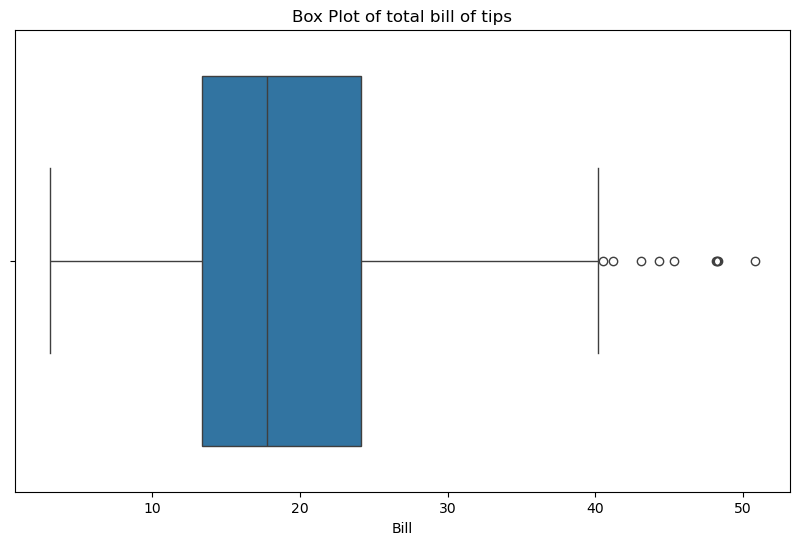

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df['total_bill'], orient='h')
plt.title('Box Plot of total bill of tips')
plt.xlabel("Bill")
plt.show()

In [7]:
df=pd.read_csv('titanic.csv')

In [8]:
five_point_summary =df['age'].describe()[['min','25%','50%','75%','max']]
print("5-Point Summary:")
print(five_point_summary)


5-Point Summary:
min     0.420
25%    20.125
50%    28.000
75%    38.000
max    80.000
Name: age, dtype: float64


In [9]:
Q1= df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
IQR=Q3 -Q1
print("IQR:" , IQR)

IQR: 17.875


In [10]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -6.6875
Upper Bound: 64.8125


In [11]:
#Data Cleaning (Handling Nulls)
#Two techniques: Pandas or SimpleImputer class from scikit-learn
#Three approaches:Replace with mean/median,zeroes,drop(not implemented here)

In [12]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


#### 2) Do outlier analysis on age column of titanic dataset.

In [13]:
import pandas as pd 
from sklearn.impute import SimpleImputer

In [14]:
df = pd.read_csv('titanic.csv')

In [15]:
#Handling Null Values
df['age_mean']=df['age'].fillna(df['age'].mean())
df['age_median']=df['age'].fillna(df['age'].median())
df['age_mode']=df['age'].fillna(df['age'].mode()[0])
df['age_constant']=df['age'].fillna(0)

In [16]:
#Handling nulls using SimpleImputer of scikitlearn library
imp_mean=SimpleImputer(strategy='mean')
df['age_imputer_mean']=imp_mean.fit_transform(df[['age']])
imp_median=SimpleImputer(strategy='median')
df['age_imputer_median']=imp_median.fit_transform(df[['age']])
imp_mode=SimpleImputer(strategy='most_frequent')
df['age_imputer_mode']=imp_mode.fit_transform(df[['age']])
imp_const = SimpleImputer(strategy='constant',fill_value=0)
df['age_imputer_constant']=imp_const.fit_transform(df[['age']])

print(df[['age','age_mean','age_median','age_mode','age_constant','age_imputer_mean','age_imputer_median','age_imputer_mode','age_imputer_constant']])

      age   age_mean  age_median  age_mode  age_constant  age_imputer_mean  \
0    22.0  22.000000        22.0      22.0          22.0         22.000000   
1    38.0  38.000000        38.0      38.0          38.0         38.000000   
2    26.0  26.000000        26.0      26.0          26.0         26.000000   
3    35.0  35.000000        35.0      35.0          35.0         35.000000   
4    35.0  35.000000        35.0      35.0          35.0         35.000000   
..    ...        ...         ...       ...           ...               ...   
886  27.0  27.000000        27.0      27.0          27.0         27.000000   
887  19.0  19.000000        19.0      19.0          19.0         19.000000   
888   NaN  29.699118        28.0      24.0           0.0         29.699118   
889  26.0  26.000000        26.0      26.0          26.0         26.000000   
890  32.0  32.000000        32.0      32.0          32.0         32.000000   

     age_imputer_median  age_imputer_mode  age_imputer_constant

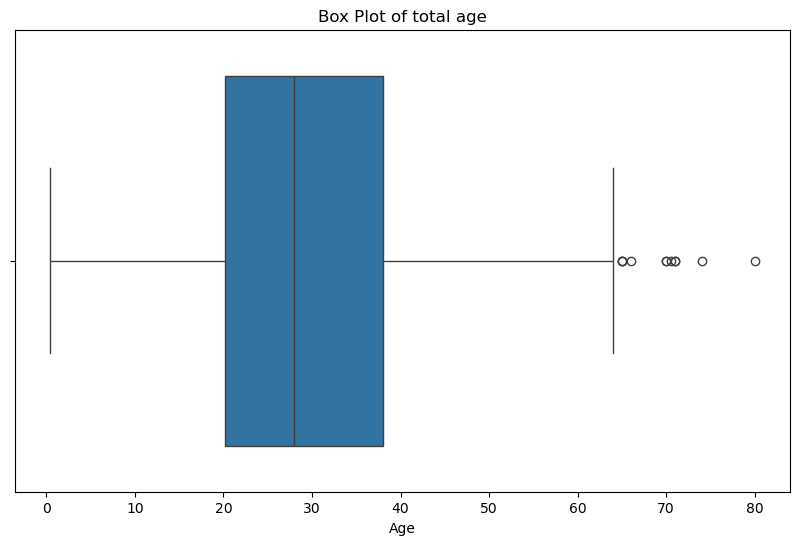

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df['age'], orient='h')
plt.title('Box Plot of total age')
plt.xlabel("Age")
plt.show()